# 03 — Não Supervisionado: Perfis de Usuários

## Bloco 1 — Contexto e pergunta

No notebook anterior, a pergunta tinha resposta no dataset: a nota registrava se o usuário gostou ou não. Agora a pergunta muda de natureza:

**Que tipos de usuários temos?**

Não há uma coluna que responda isso. O dataset não traz uma etiqueta "tipo de usuário" — esse rótulo não existe. O objetivo não é prever uma variável conhecida, mas **descobrir estrutura** nos padrões de consumo.

| Aspecto | Supervisionado | Não supervisionado |
|---|---|---|
| Existe rótulo? | Sim — `gostou` derivado da `rating` | Não |
| O que o algoritmo faz? | Aprende a prever `y` dado `x` | Organiza os dados em grupos similares |
| O que se obtém? | Previsão por amostra | Segmentos, perfis, representações |

O mesmo dataset MovieLens — sem nenhuma coluna nova — pode revelar grupos naturais de usuários por meio dos padrões de avaliação por gênero.

## Informações do notebook

| Item | Detalhe |
|---|---|
| **Aula** | Aula 01 — Paradigmas de ML com MovieLens |
| **Notebook** | 03 — Não supervisionado: Perfis de usuários |
| **Seções** | 1.3 — Aprendizado não supervisionado |
| **Tempo de leitura** | 12 min |
| **Tempo de execução (padrão)** | 5 min |
| **Exercícios** | 3 questões de autoavaliação |

### Pré-requisitos

- **Notebooks anteriores:** `01_contexto_movielens.ipynb` — dados disponíveis em `data/movielens/`.
- **Conceitos:** features, normalização, distância euclidiana.

### Competências para o Desafio Final

- Segmentar usuários por perfil de consumo para reduzir o espaço do problema de recomendação.
- Interpretar clusters como contextos (estados) aproximados para um agente de RL.
- Identificar quando a ausência de rótulo torna o não supervisionado a abordagem adequada.

### Recapitulando

No notebook anterior aplicamos **regressão logística** para prever se um usuário vai gostar de um filme. O modelo usa rótulo explícito (`gostou = nota ≥ 4`). A limitação central: o supervisionado não descobre quais perfis de usuário existem no catálogo — ele só responde a pares já observados.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0


torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1


scikit-learn         1.8.0


## Bloco 2 — Mini teoria

### Aprendizado sem rótulo

No aprendizado não supervisionado, o conjunto de dados não contém variável-alvo. O algoritmo opera apenas sobre as features `x` e busca organizar os dados de forma que observações similares fiquem próximas e observações distintas fiquem separadas.

O critério de "semelhança" é definido matematicamente — não por uma resposta humana prévia.

### Clusterização: grupos naturais nos dados

A clusterização divide o espaço de features em regiões coesas. O algoritmo **K-Means** é o mais comum:

1. Define `k` centróides aleatórios.
2. Atribui cada ponto ao centróide mais próximo (distância euclidiana).
3. Recalcula os centróides como média dos pontos atribuídos.
4. Repete os passos 2 e 3 até convergência.

O resultado é uma partição dos dados em `k` grupos, onde cada grupo representa um perfil latente — neste caso, um tipo de usuário definido pelas preferências de gênero.

### Redução de dimensionalidade para visualização

Com mais de 2 features, não é possível visualizar os clusters diretamente. A **Análise de Componentes Principais (PCA)** projeta os dados em 2 dimensões preservando a maior parte da variância. O gráfico 2D resultante não é o espaço onde o K-Means rodou — é uma projeção para facilitar a inspeção visual dos grupos.

### Limitações

O não supervisionado descobre padrões, mas não gera uma decisão direta. Saber que um usuário pertence ao "perfil de fã de drama" não determina automaticamente qual filme mostrar agora. Para isso, é necessário um mecanismo de ação e feedback — que é o que o Aprendizado por Reforço modela.

## Exemplo mínimo: 4 usuários, 2 gêneros, 2 clusters

Antes do K-Means no dataset completo, quatro usuários fictícios com preferências em dois gêneros mostram como o algoritmo agrupa pontos similares. Com apenas 2 dimensões é possível visualizar e acompanhar cada iteração manualmente — sem qualquer biblioteca de ML.

K-Means manual: k=2, dimensões = (nota_action, nota_drama)

  Usuário   nota_action  nota_drama
--------------------------------------
       U1           4.5         1.5
       U2           4.2         2.0
       U3           1.8         4.3
       U4           2.1         4.6

Iteração 1: clusters=[0, 0, 1, 1]  centróides=[[4.35, 1.75], [1.95, 4.45]]  Δ=0.624
Iteração 2: clusters=[0, 0, 1, 1]  centróides=[[4.35, 1.75], [1.95, 4.45]]  Δ=0.000
Iteração 3: clusters=[0, 0, 1, 1]  centróides=[[4.35, 1.75], [1.95, 4.45]]  Δ=0.000

Resultado: U1/U2 → cluster 0 (fã de action) | U3/U4 → cluster 1 (fã de drama)


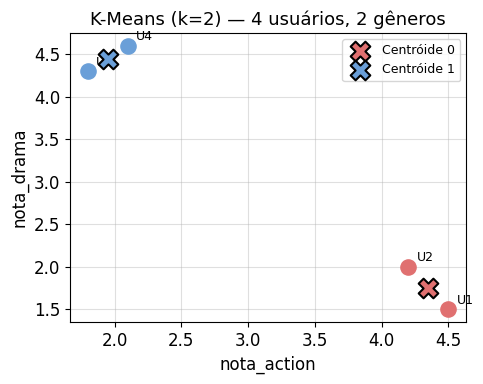

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 4 usuários: (nota_action, nota_drama) — sem rótulo
perfis = np.array([
    [4.5, 1.5],  # fã de action
    [4.2, 2.0],  # fã de action
    [1.8, 4.3],  # fã de drama
    [2.1, 4.6],  # fã de drama
])
nomes = ['U1', 'U2', 'U3', 'U4']

print("K-Means manual: k=2, dimensões = (nota_action, nota_drama)\n")
print(f"{'Usuário':>9} {'nota_action':>13} {'nota_drama':>11}")
print("-" * 38)
for n, p in zip(nomes, perfis):
    print(f"{n:>9} {p[0]:13.1f} {p[1]:11.1f}")

# Centróides iniciais: baseados em conhecimento dos dados (para clareza didática)
centroides = np.array([[4.0, 2.0], [2.0, 4.0]], dtype=float)
print()

for iteracao in range(1, 4):
    clusters  = [int(np.argmin([np.linalg.norm(p - c) for c in centroides])) for p in perfis]
    novos_c   = np.array([perfis[np.array(clusters) == k].mean(axis=0) for k in range(2)])
    delta     = np.linalg.norm(novos_c - centroides)
    centroides = novos_c
    print(f"Iteração {iteracao}: clusters={clusters}  centróides={novos_c.round(2).tolist()}  Δ={delta:.3f}")

print(f"\nResultado: U1/U2 → cluster 0 (fã de action) | U3/U4 → cluster 1 (fã de drama)")

CORES = ['#e07070', '#6a9fd8']
fig, ax = plt.subplots(figsize=(5, 4))
for i, (p, n) in enumerate(zip(perfis, nomes)):
    ax.scatter(*p, color=CORES[clusters[i]], s=120, zorder=3)
    ax.annotate(n, p, textcoords='offset points', xytext=(6, 4), fontsize=9)
for k, c in enumerate(centroides):
    ax.scatter(*c, marker='X', s=200, color=CORES[k], edgecolors='k', linewidths=1.5, zorder=4,
               label=f'Centróide {k}')
ax.set_xlabel('nota_action')
ax.set_ylabel('nota_drama')
ax.set_title('K-Means (k=2) — 4 usuários, 2 gêneros')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Autoavaliação

<details>
<summary>Pergunta 1: Por que o K-Means não precisa de rótulos para encontrar grupos nos dados?</summary>

**Resposta:** Porque o K-Means define similaridade geometricamente — pela distância euclidiana entre pontos no espaço de features. O algoritmo não precisa saber o que cada grupo "significa": ele apenas agrupa os pontos que estão próximos entre si e separa os que estão distantes. Os rótulos interpretativos (ex.: "fã de drama") são atribuídos pelo analista *após* a clusterização, não pelo algoritmo.

**Por quê:** Aprendizado não supervisionado descobre estrutura intrínseca dos dados — padrões que existem nos dados independentemente de qualquer definição humana prévia.

</details>

<details>
<summary>Pergunta 2: O que o PCA faz e o que ele NÃO faz neste notebook?</summary>

**Resposta:** O PCA projeta o espaço de features de alta dimensão (5 dimensões: `qtd_avaliacoes` + 4 notas de gênero) em 2 dimensões preservando a maior parte da variância. Ele é usado **apenas para visualização** — o K-Means já foi executado no espaço original de 5 dimensões. O PCA não influencia os clusters; apenas permite enxergá-los em um gráfico 2D.

**Por quê:** Confundir PCA com clustering é um erro comum. Os clusters são determinados pela distância no espaço original — o PCA 2D é uma janela para inspecionar visualmente o que o K-Means encontrou.

</details>

<details>
<summary>Pergunta 3: Como os clusters de usuários poderiam ser usados como estados em um sistema de RL para recomendação?</summary>

**Resposta:** O cluster de um usuário pode representar o *estado* do agente de RL. Em vez de um estado contínuo de alta dimensão (histórico completo de avaliações), o agente observa "usuário no cluster 2" — um estado discreto e tratável. A política aprendida pelo RL seria: "dado que o usuário está no cluster 2, qual filme recomendar para maximizar o engajamento?" Isso combina a compressão do não supervisionado com a decisão do RL.

**Por quê:** Estados de alta dimensão dificultam a generalização em RL. Segmentação prévia comprime o espaço de estados e torna o problema mais tratável — esse é um padrão comum em sistemas de recomendação reais.

</details>

## Considerações éticas e de fairness na segmentação

A clusterização de usuários pode introduzir vieses sistêmicos quando os perfis aprendidos refletem desigualdades históricas de acesso ou representação nos dados:

**Viés de cobertura:** se certos grupos demográficos avaliam menos filmes por barreiras de acesso (preço, idioma, disponibilidade regional), seus perfis ficam sub-representados. Um cluster rotulado "usuário casual" pode capturar usuários com menos acesso à plataforma do que usuários com menor interesse genuíno.

**Reforço de bolhas de filtro:** segmentar por gênero preferido e recomendar apenas dentro do segmento reduz a diversidade de exposição. Um fã de drama nunca seria exposto a documentários que poderia apreciar. A métrica de *cobertura* — proporção do catálogo efetivamente recomendada — deve complementar a de engajamento.

**Estabilidade do perfil:** usuários que mudam de preferências (ex.: descobrem novo gênero) permanecem mal classificados até a próxima rodada de treinamento. Sistemas em produção devem reclusterizar com frequência ou usar representações dinâmicas de perfil.

**Boas práticas para o Desafio Final:** ao usar clusters como estados do agente de RL, reportar a distribuição de usuários por cluster, verificar se grupos minoritários estão representados proporcionalmente, e monitorar se a política aprendida trata todos os segmentos com diversidade adequada de recomendação.

## Bloco 3 — Código didático mínimo

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

RATINGS_PATH = 'data/movielens/ratings.csv'
MOVIES_PATH  = 'data/movielens/movies.csv'
SEED = 42

GENEROS = ['Action', 'Comedy', 'Drama', 'Romance']

try:
    ratings = pd.read_csv(RATINGS_PATH)
    movies  = pd.read_csv(MOVIES_PATH)
except FileNotFoundError as e:
    raise FileNotFoundError(
        f'{e}\nExecute o notebook 01_contexto_movielens.ipynb para preparar os dados.'
    )

# Enriquecer ratings com gêneros dos filmes
merged = ratings.merge(movies[['movieId', 'genres']], on='movieId', how='left')

# Média de nota por usuário para cada gênero de interesse
user_stats = ratings.groupby('userId').agg(
    qtd_avaliacoes=('rating', 'count')
).reset_index()

media_global_usuario = ratings.groupby('userId')['rating'].mean().rename('media_global')
user_stats = user_stats.merge(media_global_usuario.reset_index(), on='userId')

for genero in GENEROS:
    col  = f'nota_{genero.lower()}'
    mask = merged['genres'].fillna('').str.contains(genero, regex=False)
    serie = merged[mask].groupby('userId')['rating'].mean().rename(col)
    user_stats = user_stats.merge(serie.reset_index(), on='userId', how='left')
    # Usuários sem avaliação nesse gênero recebem sua média global
    user_stats[col] = user_stats[col].fillna(user_stats['media_global'])

user_stats = user_stats.drop(columns=['media_global'])

FEATURE_COLS = ['qtd_avaliacoes'] + [f'nota_{g.lower()}' for g in GENEROS]

print(f'Usuários com perfil construído: {len(user_stats):,}')
print('\nAmostra de perfis de usuário:')
display(user_stats[['userId'] + FEATURE_COLS].head(8).round(2))

Usuários com perfil construído: 610

Amostra de perfis de usuário:


,userId,qtd_avaliacoes,nota_action,nota_comedy,nota_drama,nota_romance
0,1,232,4.32,4.28,4.53,4.31
1,2,29,3.95,4.00,3.88,4.50
2,3,39,3.57,1.00,0.75,0.50
3,4,216,3.32,3.51,3.48,3.38
4,5,44,3.11,3.47,3.80,3.09
5,6,314,3.61,3.37,3.61,3.61
6,7,152,3.26,3.16,3.13,2.65
7,8,47,3.33,3.21,3.79,3.50


In [4]:
X = user_stats[FEATURE_COLS].values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

km = KMeans(n_clusters=3, random_state=SEED, n_init=10)
user_stats['cluster'] = km.fit_predict(X_sc)

# Tamanho de cada cluster
tamanhos = (
    user_stats['cluster'].value_counts().sort_index()
    .rename('usuários').rename_axis('cluster').reset_index()
)
tamanhos['proporção'] = (tamanhos['usuários'] / tamanhos['usuários'].sum()).round(3)
print('Tamanho de cada cluster:')
display(tamanhos)

# Médias das features por cluster
medias_cluster = user_stats.groupby('cluster')[FEATURE_COLS].mean().round(2)
print('\nMédia de cada feature por cluster:')
display(medias_cluster)

Tamanho de cada cluster:


,cluster,usuários,proporção
0,0,345,0.566
1,1,24,0.039
2,2,241,0.395



Média de cada feature por cluster:


,qtd_avaliacoes,nota_action,nota_comedy,nota_drama,nota_romance
cluster,,,,,
0,111.08,3.90,3.90,4.08,4.01
1,1203.42,3.18,3.17,3.46,3.26
2,139.55,3.10,3.13,3.33,3.14


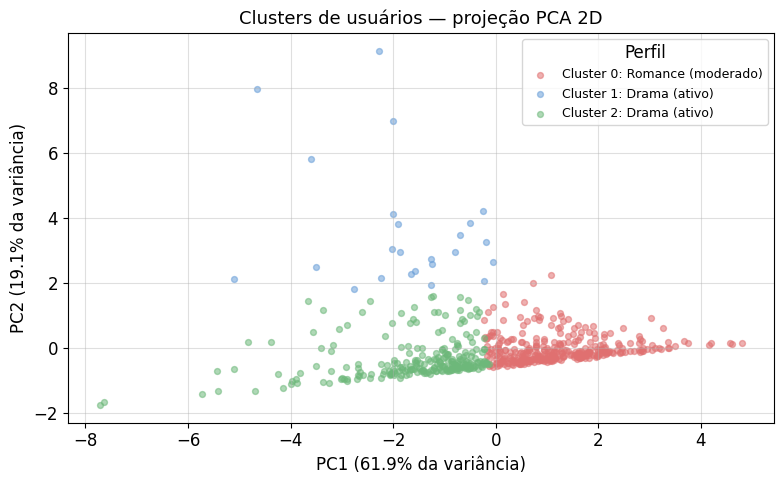

Variância explicada pelos 2 componentes: 81.0%


In [5]:
# Requer execução de ul5ro5l0hv9 (X_sc, medias_cluster)
# Rótulo interpretativo: gênero com maior desvio acima da média geral por cluster
GENRE_COLS  = [f'nota_{g.lower()}' for g in GENEROS]
media_geral = user_stats[GENRE_COLS].mean()
CORES       = ['#e07070', '#6a9fd8', '#6db87a']

rotulos = {}
for c in sorted(user_stats['cluster'].unique()):
    row   = medias_cluster.loc[c, GENRE_COLS]
    dom   = (row - media_geral).idxmax().replace('nota_', '').capitalize()
    qtd_c = medias_cluster.loc[c, 'qtd_avaliacoes']
    p33   = user_stats['qtd_avaliacoes'].quantile(0.33)
    p66   = user_stats['qtd_avaliacoes'].quantile(0.66)
    nivel = 'ativo' if qtd_c >= p66 else ('casual' if qtd_c <= p33 else 'moderado')
    rotulos[c] = f'Cluster {c}: {dom} ({nivel})'

pca = PCA(n_components=2, random_state=SEED)
Z   = pca.fit_transform(X_sc)
var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 5))
for c in sorted(user_stats['cluster'].unique()):
    mask = user_stats['cluster'].values == c
    ax.scatter(Z[mask, 0], Z[mask, 1],
               c=CORES[c % len(CORES)], label=rotulos[c],
               alpha=0.55, s=18)

ax.set_xlabel(f'PC1 ({var[0]:.1f}% da variância)')
ax.set_ylabel(f'PC2 ({var[1]:.1f}% da variância)')
ax.set_title('Clusters de usuários — projeção PCA 2D')
ax.legend(title='Perfil', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Variância explicada pelos 2 componentes: {sum(var):.1f}%')

## Glossário — termos introduzidos neste notebook

| Termo (EN) | Tradução (PT) | Descrição |
|---|---|---|
| clustering | clusterização | Agrupamento de observações similares sem rótulo explícito. |
| K-Means | K-Means | Algoritmo que divide dados em k grupos minimizando a variância intra-cluster. |
| centroid | centróide | Ponto central de um cluster, calculado como média dos pontos atribuídos. |
| PCA | PCA | Principal Component Analysis — projeta dados em 2D preservando a maior variância. |
| explained variance | variância explicada | Proporção da variância total capturada pelos componentes selecionados. |

> Glossário completo do curso: [docs/glossario.md](../../docs/glossario.md)

## Bloco 4 — Interpretação pedagógica

### O que cada cluster representa em linguagem de negócio

A tabela de médias por cluster revela três perfis distintos de usuário. A interpretação de cada um parte de duas dimensões principais: **volume de avaliações** (quão ativo é o usuário) e **preferência de gênero** (para qual tipo de conteúdo o usuário tende a dar notas mais altas).

- O cluster com maior `qtd_avaliacoes` corresponde a usuários altamente engajados — assistem e avaliam com frequência, distribuindo sua atenção por múltiplos gêneros. Para esses usuários, recomendações de novidades têm maior probabilidade de engajamento.
- O cluster com preferência concentrada em gêneros de ação ou aventura representa espectadores com gosto mais definido — as médias desses gêneros superam as dos demais. Uma estratégia de recomendação pode explorar essa consistência.
- O cluster com preferência por drama ou romance tende a notas mais altas em narrativas de personagens. Esses usuários costumam ser mais seletivos e avaliam com menor frequência.

### Como segmentação apoia recomendação

O conhecimento dos clusters pode orientar decisões de negócio sem precisar de decisão individual em tempo real:

- **Catálogo personalizado por segmento:** exibir para o segmento de ação títulos recém-adicionados desse gênero antes de recomendar itens genéricos.
- **Cold start parcial:** quando um novo usuário fornece poucos dados, atribuí-lo provisoriamente ao cluster mais próximo permite uma estratégia inicial coerente.
- **Avaliação de campanha:** medir o engajamento por cluster ajuda a identificar quais segmentos respondem melhor a determinado tipo de conteúdo.

### O que a segmentação não resolve

Segmentar usuários em perfis é uma operação em lote sobre dados históricos. Ela não responde à pergunta operacional de tempo real: dado *este* usuário, *neste* momento, *qual* filme mostrar agora? Essa decisão exige um mecanismo que aja, observe o resultado e ajuste a estratégia — o que é o domínio do Aprendizado por Reforço.

## Bloco 5 — Limites e transição

### O que a segmentação não resolve por si só

A clusterização responde bem à pergunta "que tipos de usuários existem?", mas deixa sem resposta as perguntas operacionais:

- **"Qual filme recomendar agora para este usuário?"** — Saber o perfil do usuário reduz o espaço de candidatos, mas não determina a escolha. Dentro de um segmento de "fã de drama", há centenas de filmes possíveis. Uma estratégia de seleção ainda é necessária.
- **"Como aprender com o feedback ao longo do tempo?"** — Os clusters são calculados em lote sobre dados históricos. Cada nova interação do usuário não atualiza a política de recomendação automaticamente. O sistema não aprende com o resultado de cada decisão individual.
- **"O que acontece quando o usuário muda de preferência?"** — Perfis estáticos não capturam deriva de interesse. Um usuário que começa a assistir mais comédias após uma sequência de dramas permanece no mesmo cluster até uma nova rodada de treinamento.

Essas limitações não tornam o não supervisionado inútil — pelo contrário, ele é um pré-processamento valioso e pode alimentar sistemas mais complexos. Mas o problema de decisão sequencial com feedback requer um paradigma diferente.

### O que vem a seguir

O próximo notebook aborda a terceira formulação:

**Qual filme recomendar agora para maximizar o engajamento ao longo do tempo?**

Essa pergunta define um problema de decisão sequencial. A resposta é o Aprendizado por Reforço, onde o sistema age, observa a recompensa e ajusta sua política de recomendação a cada interação.

## Leituras e referências

- MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the 5th Berkeley Symposium on Mathematical Statistics and Probability*, 1, 281–297.
- Jolliffe, I. T. *Principal Component Analysis*. Springer, 2002. (Referência para PCA e redução de dimensionalidade.)
- Pedregosa, F. et al. Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830, 2011. Disponível em: https://scikit-learn.org (acesso em 2026-03-07).
- MovieLens (GroupLens): https://grouplens.org/datasets/movielens/ (acesso em 2026-03-07).
- Roteiro da Aula 01, Vídeo 3: `roteiros/Aula 01 - Roteiro video aula.md`.